In [7]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt

import importlib
import model
importlib.reload(model)
from model import SLRHybridModel


In [8]:
CONFIG = {
    "num_classes": 353,      
    "batch_size": 32,         
    "lr": 5e-4,              
    "weight_decay": 1e-4,    
    "epochs": 50,           
    "patience": 15,         
    "input_dim": 99,
    "hidden_dim": 128,      
    "experiment_name": "SSL400-Hybrid-Final-Optimized-center landmarks",
    "mlflow_tracking_uri": "./mlruns"
}

Training on: cpu


2026/05/07 16:30:03 INFO mlflow.tracking.fluent: Experiment with name 'SSL400-Hybrid-Final-Optimized-center landmarks' does not exist. Creating a new experiment.



Starting training for 353 classes...
Epoch 000 | Train Acc: 0.0517 | Val Acc: 0.1440 | Val Loss: 4.5546
  --> New Best Val Accuracy: 0.1440 (Saved)
Epoch 000 | Train Acc: 0.0517 | Val Acc: 0.1440 | Val Loss: 4.5546
  --> New Best Val Accuracy: 0.1440 (Saved)
Epoch 001 | Train Acc: 0.0995 | Val Acc: 0.2179 | Val Loss: 4.2599
  --> New Best Val Accuracy: 0.2179 (Saved)
Epoch 001 | Train Acc: 0.0995 | Val Acc: 0.2179 | Val Loss: 4.2599
  --> New Best Val Accuracy: 0.2179 (Saved)
Epoch 002 | Train Acc: 0.1446 | Val Acc: 0.2996 | Val Loss: 3.9255
  --> New Best Val Accuracy: 0.2996 (Saved)
Epoch 002 | Train Acc: 0.1446 | Val Acc: 0.2996 | Val Loss: 3.9255
  --> New Best Val Accuracy: 0.2996 (Saved)
Epoch 003 | Train Acc: 0.1967 | Val Acc: 0.3774 | Val Loss: 3.7005
  --> New Best Val Accuracy: 0.3774 (Saved)
Epoch 003 | Train Acc: 0.1967 | Val Acc: 0.3774 | Val Loss: 3.7005
  --> New Best Val Accuracy: 0.3774 (Saved)
Epoch 004 | Train Acc: 0.2407 | Val Acc: 0.4241 | Val Loss: 3.4953
  --> N

2026/05/07 16:36:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 045 | Train Acc: 0.9648 | Val Acc: 0.7471 | Val Loss: 2.5162

Early stopping triggered after 45 epochs.


2026/05/07 16:36:51 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Training complete. Best Validation Accuracy: 75.8755%


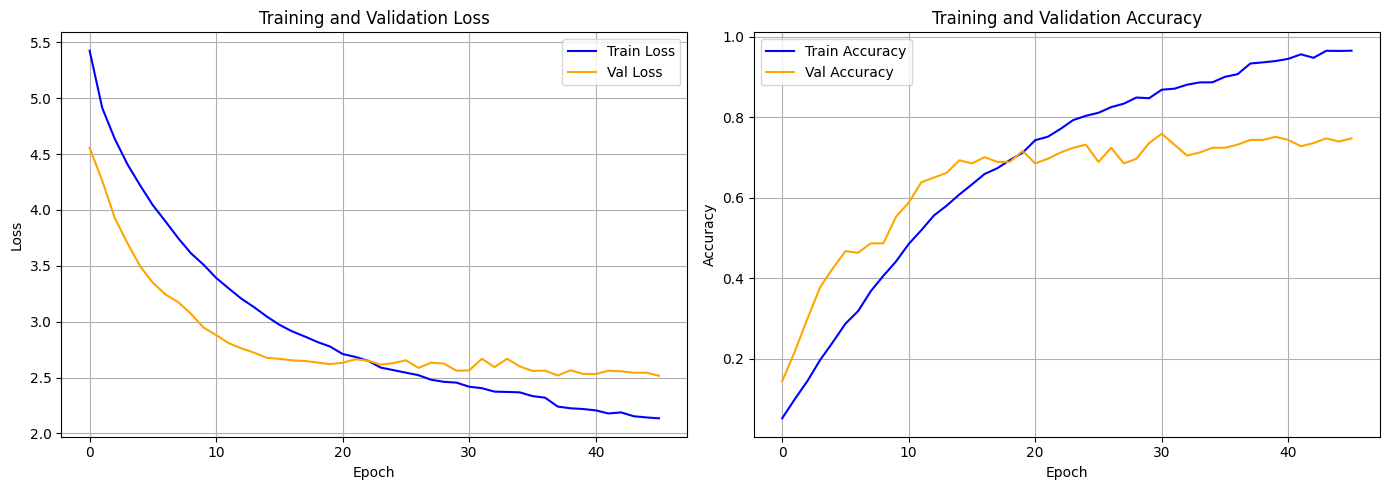

In [9]:

def train_hybrid():
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    
    
    data_dir = "../../ssl400_processed_paper"
    try:
        train_data = np.load(os.path.join(data_dir, "train_data.npz"))
        val_data = np.load(os.path.join(data_dir, "val_data.npz"))
        
        X_train = torch.from_numpy(train_data["X"]).float()
        y_train = torch.from_numpy(train_data["y"]).long()
        X_val = torch.from_numpy(val_data["X"]).float()
        y_val = torch.from_numpy(val_data["y"]).long()
    except FileNotFoundError:
        print(f"Error: Data files not found in {data_dir}. Run preprocess_paper.py first.")
        return

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=CONFIG["batch_size"], shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=CONFIG["batch_size"])

    
    model_instance = SLRHybridModel(CONFIG["num_classes"], CONFIG["input_dim"], CONFIG["hidden_dim"]).to(device)
    
    
    optimizer = torch.optim.AdamW(model_instance.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2) 
    
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    
   
    mlflow.set_tracking_uri(CONFIG["mlflow_tracking_uri"])
    mlflow.set_experiment(CONFIG["experiment_name"])
    
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    with mlflow.start_run():
        mlflow.log_params(CONFIG)
        mlflow.log_param("param_count", sum(p.numel() for p in model_instance.parameters()))

        best_val_acc = 0.0
        early_stop_counter = 0

        print(f"\nStarting training for {CONFIG['num_classes']} classes...")
        for epoch in range(CONFIG["epochs"]):
            
            model_instance.train()
            train_loss, train_correct = 0, 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                
                optimizer.zero_grad()
                output = model_instance(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                
                
                torch.nn.utils.clip_grad_norm_(model_instance.parameters(), max_norm=1.0)
                optimizer.step()
                
                train_loss += loss.item()
                train_correct += (output.argmax(1) == y_batch).type(torch.float).sum().item()

            model_instance.eval()
            val_loss, val_correct = 0, 0
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    output = model_instance(X_batch)
                    val_loss += criterion(output, y_batch).item()
                    val_correct += (output.argmax(1) == y_batch).type(torch.float).sum().item()

           
            train_acc = train_correct / len(X_train)
            val_acc = val_correct / len(X_val)
            avg_train_loss = train_loss / len(train_loader)
            avg_val_loss = val_loss / len(val_loader)

            
            history["train_loss"].append(avg_train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(avg_val_loss)
            history["val_acc"].append(val_acc)

            mlflow.log_metrics({
                "train_loss": avg_train_loss,
                "train_acc": train_acc,
                "val_loss": avg_val_loss,
                "val_acc": val_acc
            }, step=epoch)

            scheduler.step(val_acc)

            print(f"Epoch {epoch:03d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {avg_val_loss:.4f}")

           
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model_instance.state_dict(), "best_hybrid_model.pt")
                early_stop_counter = 0
                print(f"  --> New Best Val Accuracy: {best_val_acc:.4f} (Saved)")
            else:
                early_stop_counter += 1
            
            if early_stop_counter >= CONFIG["patience"]:
                print(f"\nEarly stopping triggered after {epoch} epochs.")
                break

        
        mlflow.pytorch.log_model(model_instance, "model")
        print(f"\nTraining complete. Best Validation Accuracy: {best_val_acc:.4%}")

    
    plt.figure(figsize=(14, 5))

    
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss", color='blue')
    plt.plot(history["val_loss"], label="Val Loss", color='orange')
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Accuracy", color='blue')
    plt.plot(history["val_acc"], label="Val Accuracy", color='orange')
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_hybrid()